In [42]:
import numpy as np
print(np.__version__)

2.4.2


In [53]:
softmax_outputs = np.array([[0.7, 0.1, 0.3],[0.4, 0.55, 0.05],[0.05, 0.01, 0.94]])
print(softmax_outputs)
class_targets = [0, 1, 2]
print(softmax_outputs[[0, 1, 2], class_targets])

[[0.7  0.1  0.3 ]
 [0.4  0.55 0.05]
 [0.05 0.01 0.94]]
[0.7  0.55 0.94]


In [54]:
print(-np.log(softmax_outputs[[0, 1, 2], class_targets]))

[0.35667494 0.597837   0.0618754 ]


In [55]:
(len(softmax_outputs))

3

In [56]:
softmax_outputs[range(len(softmax_outputs)), class_targets]

array([0.7 , 0.55, 0.94])

In [57]:
print(-np.log(softmax_outputs[
    range(len(softmax_outputs)), class_targets]))
neg_loss = -np.log(softmax_outputs[
    range(len(softmax_outputs)), class_targets])
avrg_loss = np.mean(neg_loss)
print(avrg_loss)

[0.35667494 0.597837   0.0618754 ]
0.3387957828041468


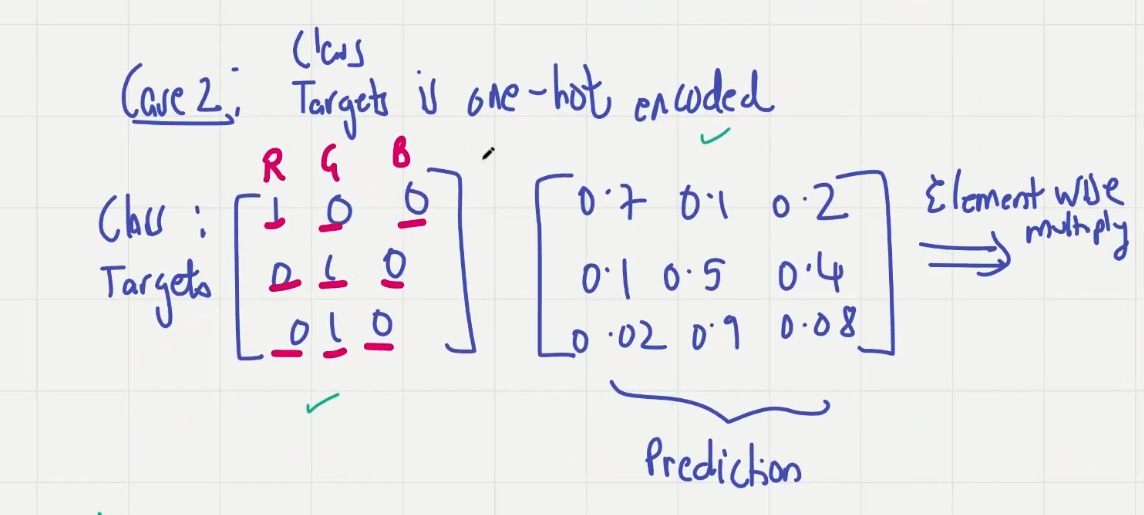

In [58]:
y_true = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])

y_pred = softmax_outputs

A = y_true * y_pred
B = np.sum(A, axis = 1)
C = - np.log(B)

print(C)
print(np.mean(C))

[0.35667494 0.597837   0.0618754 ]
0.3387957828041468


In [59]:
class Loss:
    def calculate(self, output, y):
        sample_loss = self.forward(output, y)
        data_loss = np.mean(sample_loss)
        return data_loss

In [60]:
class Loss_Categorical_Crossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_c = np.clip(y_pred, 1e-7, 1 - 1e-7)

        if len(y_true.shape) == 1:
            conf= y_pred_c[
                range(samples),
                y_true
                ]
        elif len(y_true.shape) == 2:
            conf = np.sum(
                y_pred_c * y_true,
                axis=1,
            )

        neg_log_lhood = -np.log(conf)
        return neg_log_lhood
        
            

In [61]:
softmax_outputs = np.array([[0.7, 0.1, 0.3],[0.4, 0.55, 0.05],[0.05, 0.01, 0.94]])
print(softmax_outputs)
class_targets = np.array([0, 1, 2])
y_true = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])

loss_fn = Loss_Categorical_Crossentropy()
loss = loss_fn.calculate(softmax_outputs, y_true)
print(loss)

[[0.7  0.1  0.3 ]
 [0.4  0.55 0.05]
 [0.05 0.01 0.94]]
0.3387957828041468


In [62]:
class Activation_Softmax:

    def forward(self, inputs):
        self.input = inputs
        exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        prob = exp_vals/np.sum(exp_vals, axis=1, keepdims=True)
        self.output = prob
        #return prob

class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)
        return self.output

In [71]:
import numpy as np
import nnfs 
from nnfs.datasets import spiral_data
nnfs.init()

#Dense layer
class Layer_Dense:
    #layer init
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) #not n_neurons x n_inputs --> 
        self.biases = np.zeros((1, n_neurons))                     #to avoid the transpose in dot products

    #forward pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output                                        

#Create dataset
X, y = spiral_data(samples=100, classes=3)
#X, y = np.random.randn(3, 3), np.random.randint(low=0, high=2, size=(3, ))
print("y:",y[:5])
print(f"X, Y shape:{X.shape}, {y.shape}")


dense1 = Layer_Dense(2, 5)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(5, 3)
activation2  = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

loss_fn = Loss_Categorical_Crossentropy()
loss = loss_fn.calculate(activation2.output, y)
print("Loss:", loss)  

#print(activation2.output[:5])

# print("X shape:", X.shape)
# print("dense2 weights shape:", dense2.weights.shape)
# print("final output shape:", activation2.output.shape)

predictions = np.argmax(activation2.output, axis=1)
if len(y.shape) == 2:
    y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)

print('acc:', accuracy)

y: [0 0 0 0 0]
X, Y shape:(300, 2), (300,)
Loss: 1.098615
acc: 0.35333333333333333
